# Check if Libraries are downloaded 

In [2]:
# List of required libraries
required_libraries = [
    'pandas',        # For data manipulation and analysis
    'os',            # For interacting with the operating system
    'numpy',         # For numerical operations on data
    'wfdb',          # For working with ECG data files
    'ast',           # For literal evaluation of SCP codes
    'tqdm',          # For creating progress bars
    'IPython',       # For interactive computing
    'matplotlib',    # For creating plots and visualizations
    'seaborn',       # For enhancing plot aesthetics
    'missingno',     # For visualizing missing data in dataframes
    'scikit-learn',  # For machine learning and preprocessing
    'sys',           # For system-specific parameters and functions
    'math',          # For mathematical operations
    'tensorflow',    # For deep learning with TensorFlow
    'tensorflow.keras', # For building neural networks with Keras
    'keras',         # For loading pre-trained neural network models with Keras
    'sklearn',       # For machine learning metrics with scikit-learn
    #'PIL',           # For image processing with Pillow (PIL)
    'plot_model'      # For plotting models performance
    
]

# Create a dictionary to map library names to their import names
library_name_to_import = {
    'pandas': 'import pandas as pd',
    'os': 'import os',
    'numpy': 'import numpy as np',
    'wfdb': 'import wfdb',
    'ast': 'import ast',
    'tqdm': 'import tqdm',
    'IPython': 'from IPython import display',
    'matplotlib': 'import matplotlib.pyplot as plt',
    'seaborn': 'import seaborn as sns',
    'missingno': 'import missingno as msno',
    'scikit-learn': 'from sklearn.preprocessing import StandardScaler',
    'sys': 'import sys',
    'math': 'import math',
    'tensorflow': 'import tensorflow as tf',
    'tensorflow.keras': 'import tensorflow.keras as keras',
    'keras': 'from keras.models import load_model',
    'sklearn': 'import sklearn.metrics',
    'plot_model': 'from keras.utils import plot_model'
}

# Check and install missing libraries
missing_libraries = []

for library_name in required_libraries:
    import_statement = library_name_to_import.get(library_name)
    if import_statement:
        try:
            exec(import_statement)
        except ImportError:
            missing_libraries.append(library_name)
    else:
        missing_libraries.append(library_name)

if missing_libraries:
    print("The following libraries are missing and will be installed:")
    for library_name in missing_libraries:
        print(library_name)
        if library_name == 'wfdb':
            # Install wfdb using pip (assuming it's available on PyPI)
            os.system('pip install wfdb')
        else:
            # Install other libraries using pip
            os.system(f'pip install {library_name}')
    
    # Import the missing libraries after installation
    for library_name in missing_libraries:
        import_statement = library_name_to_import.get(library_name)
        if import_statement:
            exec(import_statement)
    
    print("Please run the code again after installation.")
else:
    # All required libraries are installed
    print("All required libraries are installed. Proceed with your code.")

# Set seaborn style for improved plot aesthetics
sns.set_style('darkgrid')


2023-10-07 12:45:38.912507: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All required libraries are installed. Proceed with your code.


# Load the dataset

In [3]:
# Define the file paths to the data files
ecg_file_path = 'ptbxl_database.csv'
scp_file_path = 'scp_statements.csv'

# Load patient metadata into ecg_dataset
ecg_dataset = pd.read_csv(ecg_file_path, index_col='ecg_id', dtype={
    'patient_id': int,
    'age': 'Int64',  # 'Int64' allows for missing values
})

# Convert the 'scp_codes' column from string to a list of codes
ecg_dataset['scp_codes'] = ecg_dataset['scp_codes'].apply(ast.literal_eval)

# Load sample metadata into scp_dataset and filter for diagnostic statements
scp_dataset = pd.read_csv(scp_file_path, index_col=0)
# Filter for diagnostic statements (where 'diagnostic' column is 1)
scp_dataset = scp_dataset[scp_dataset['diagnostic'] == 1]


ecg_dataset



,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709,56,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243,19,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372,37,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014,24,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448,19,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,17180,67,1,NaN,NaN,1.0,2.0,AT-60 3,2001-05-31 09:14:35,ventrikulÄre extrasystole(n) sinustachykardie ...,...,True,NaN,", alles,",NaN,NaN,1ES,NaN,7,records100/21000/21833_lr,records500/21000/21833_hr
21834,20703,93,0,NaN,NaN,1.0,2.0,AT-60 3,2001-06-05 11:33:39,sinusrhythmus lagetyp normal qrs(t) abnorm ...,...,True,NaN,NaN,NaN,NaN,NaN,NaN,4,records100/21000/21834_lr,records500/21000/21834_hr
21835,19311,59,1,NaN,NaN,1.0,2.0,AT-60 3,2001-06-08 10:30:27,sinusrhythmus lagetyp normal t abnorm in anter...,...,True,NaN,", I-AVR,",NaN,NaN,NaN,NaN,2,records100/21000/21835_lr,records500/21000/21835_hr


In [4]:
# Check the shape of the ECG dataframe (number of rows and columns)
ecg_shape= ecg_dataset.shape

# Print the shape with a descriptive message
print("Shape of the ECG Dataset (ecg_dataset):", ecg_shape)

Shape of the ECG Dataset (ecg_dataset): (21837, 27)


In [5]:
# Count the distribution of samples across stratified folds
stratified_counts = ecg_dataset['strat_fold'].value_counts()

# Print the counts for each fold
print("Sample Counts per Stratified Fold:")
print(stratified_counts)

# Separate the folds into training (first 8 groups) and validation/testing (last 2 groups)
training_folds = stratified_counts.index[:8]
validation_testing_folds = stratified_counts.index[8:]

# Print the training and validation/testing fold numbers
print("\nTraining Folds (First 8 Groups):", training_folds)
print("Validation/Testing Folds (Last 2 Groups):", validation_testing_folds)


Sample Counts per Stratified Fold:
strat_fold
10    2203
3     2194
9     2193
2     2184
8     2179
7     2178
6     2178
1     2177
5     2176
4     2175
Name: count, dtype: int64

Training Folds (First 8 Groups): Index([10, 3, 9, 2, 8, 7, 6, 1], dtype='int64', name='strat_fold')
Validation/Testing Folds (Last 2 Groups): Index([5, 4], dtype='int64', name='strat_fold')


In [6]:
# Define the path to the 'scp_statements.csv' file
scp_statements_file = os.path.join('scp_statements.csv')

# Load the 'scp_statements.csv' file into the agg_dataset dataframe
agg_dataset = pd.read_csv(scp_statements_file, index_col=0)

# Filter the dataframe to include only diagnostic statements (where 'diagnostic' column is 1)
agg_dataset = agg_dataset[agg_dataset['diagnostic'] == 1]

# Print the shape of the filtered dataframe
print("Shape of the Diagnostic Aggregation DataFrame (agg_dataset):", agg_dataset.shape)

# Display the first few rows of the filtered dataframe
print("\nFirst Few Rows of agg_dataset:")
print(agg_dataset.head())

Shape of the Diagnostic Aggregation DataFrame (agg_dataset): (44, 12)

First Few Rows of agg_dataset:
                          description  diagnostic  form  rhythm  \
NDT    non-diagnostic T abnormalities         1.0   1.0     NaN   
NST_          non-specific ST changes         1.0   1.0     NaN   
DIG                  digitalis-effect         1.0   1.0     NaN   
LNGQT                long QT-interval         1.0   1.0     NaN   
NORM                       normal ECG         1.0   NaN     NaN   

      diagnostic_class diagnostic_subclass  \
NDT               STTC                STTC   
NST_              STTC                NST_   
DIG               STTC                STTC   
LNGQT             STTC                STTC   
NORM              NORM                NORM   

                                      Statement Category  \
NDT                    other ST-T descriptive statements   
NST_   Basic roots for coding ST-T changes and abnorm...   
DIG                    other ST-T desc

In [7]:
# Define a function to extract diagnostic classes from SCP codes
def diagnostic_class(scp_codes):
    diagnostic_classes = set()
    for scp_code in scp_codes:
        if scp_code in agg_dataset.index:
            diagnostic_classes.add(agg_dataset.loc[scp_code].diagnostic_class)
    return list(diagnostic_classes)

# Apply the diagnostic_class function to create the 'scp_classes' column
ecg_dataset['scp_classes'] = ecg_dataset['scp_codes'].apply(diagnostic_class)


In [8]:
# Check the shape of the ecg_dataset dataframe after adding the diagnostic 
ecg_shape = ecg_dataset.shape

# Print the shape with a descriptive message
print("Shape of the ECG Dataset (ecg_dataset):", ecg_shape)

Shape of the ECG Dataset (ecg_dataset): (21837, 28)


In [9]:
# retrieves the 'scp_classes' column, which contains lists of diagnostic class
ecg_dataset['scp_classes']

ecg_id
1        [NORM]
2        [NORM]
3        [NORM]
4        [NORM]
5        [NORM]
          ...  
21833    [STTC]
21834    [NORM]
21835    [STTC]
21836    [NORM]
21837    [NORM]
Name: scp_classes, Length: 21837, dtype: object

/var/folders/nk/4d0cx0sn18x5xyc2dhmv1_240000gn/T/ipykernel_61457/3794997303.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


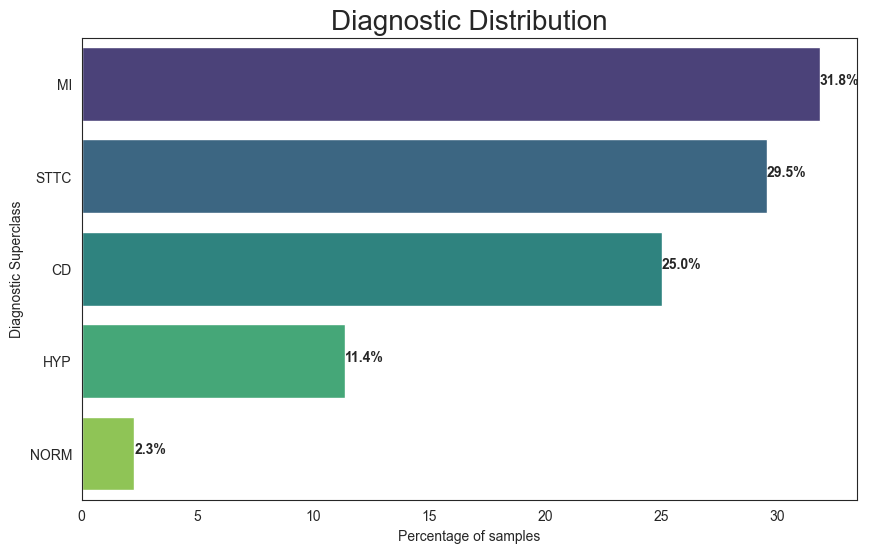

In [10]:
# Calculate value counts for 'diagnostic_class' column
value_counts = scp_dataset['diagnostic_class'].value_counts()

# Set a custom style
sns.set_style("white")

# Create a bar plot
bar, ax = plt.subplots(figsize=(10, 6))
ax = sns.barplot(
    x=value_counts.values / value_counts.values.sum() * 100.,
    y=value_counts.index,
    ci=None,
    palette="viridis",  # Change the color palette to 'viridis'
    orient='h'
)

# Set plot title and labels
ax.set_title("Diagnostic Distribution", fontsize=20)
ax.set_xlabel("Percentage of samples")
ax.set_ylabel("Diagnostic Superclass")

# Add percentage labels to the bars
for rect in ax.patches:
    ax.text(
        rect.get_width(),
        rect.get_y() + rect.get_height() / 2,
        "%.1f%%" % rect.get_width(),
        weight='bold'
    )

# Show the plot
plt.show()

# Meaning of Superclassses
NORM (Normal ECG): This category represents a normal Electrocardiogram (ECG) reading, indicating that the heart's electrical activity is within the expected range and there are no significant abnormalities.


MI (Myocardial Infarction): Myocardial Infarction, commonly known as a heart attack, occurs when there is a decrease or complete stoppage of blood flow to a part of the heart. This lack of blood flow can result in damage to the heart muscle.


STTC (ST/T Change): ST and T wave changes in an ECG may be indicative of cardiac pathology or a normal variant. Interpretation of these changes depends on the clinical context and the presence of similar findings in previous electrocardiograms.


CD (Conduction Disturbance): Conduction disturbance refers to irregularities in the way electrical impulses travel through the heart, affecting its rhythm. Some conduction disorders can lead to arrhythmias, which are irregular heartbeats.


HYP (Hypertrophy): Hypertrophic Cardiomyopathy (HCM) is a condition in which the heart muscle becomes abnormally thick (hypertrophied). This thickening can make it more challenging for the heart to pump blood efficiently, potentially leading to various cardiac issues.

In [11]:
# Define a function to load raw ECG data
def load_raw_data(df, sampling_rate):
    if sampling_rate == 100:
        data = [wfdb.rdsamp(f) for f in df.filename_lr]
    else:
        data = [wfdb.rdsamp(f) for f in df.filename_hr]
    data = np.array([signal for signal, meta in data])
    return data

# Set the desired sampling rate (e.g., 100 Hz)
sampling_rate = 100

# Load raw ECG data into the ECG_data array
ECG_data = load_raw_data(ecg_dataset, sampling_rate)

# Check the shape of the loaded ECG data
print("Shape of the Loaded Raw ECG Data (ECG_data):", ECG_data.shape)


Shape of the Loaded Raw ECG Data (ECG_data): (21837, 1000, 12)


In [12]:
print(ECG_data)

[[[-1.190e-01 -5.500e-02  6.400e-02 ... -2.600e-02 -3.900e-02 -7.900e-02]
  [-1.160e-01 -5.100e-02  6.500e-02 ... -3.100e-02 -3.400e-02 -7.400e-02]
  [-1.200e-01 -4.400e-02  7.600e-02 ... -2.800e-02 -2.900e-02 -6.900e-02]
  ...
  [ 6.900e-02  0.000e+00 -6.900e-02 ...  2.400e-02 -4.100e-02 -5.800e-02]
  [ 8.600e-02  4.000e-03 -8.100e-02 ...  2.420e-01 -4.600e-02 -9.800e-02]
  [ 2.200e-02 -3.100e-02 -5.400e-02 ...  1.430e-01 -3.500e-02 -1.200e-01]]

 [[ 4.000e-03  1.380e-01  1.340e-01 ...  1.920e-01  8.300e-02  8.800e-02]
  [-2.000e-02  1.160e-01  1.360e-01 ...  1.560e-01  5.700e-02  6.300e-02]
  [-5.300e-02  9.200e-02  1.450e-01 ...  1.070e-01  1.300e-02  2.200e-02]
  ...
  [ 1.210e-01  3.980e-01  2.770e-01 ... -1.065e+00 -4.920e-01 -1.560e-01]
  [-3.260e-01  5.700e-02  3.830e-01 ... -2.800e-01 -1.750e-01 -7.100e-02]
  [-3.480e-01 -5.600e-02  2.920e-01 ... -3.080e-01 -2.310e-01 -1.450e-01]]

 [[-2.900e-02 -7.900e-02 -4.900e-02 ... -1.030e-01 -7.600e-02 -6.600e-02]
  [-3.500e-02 -7.000e-

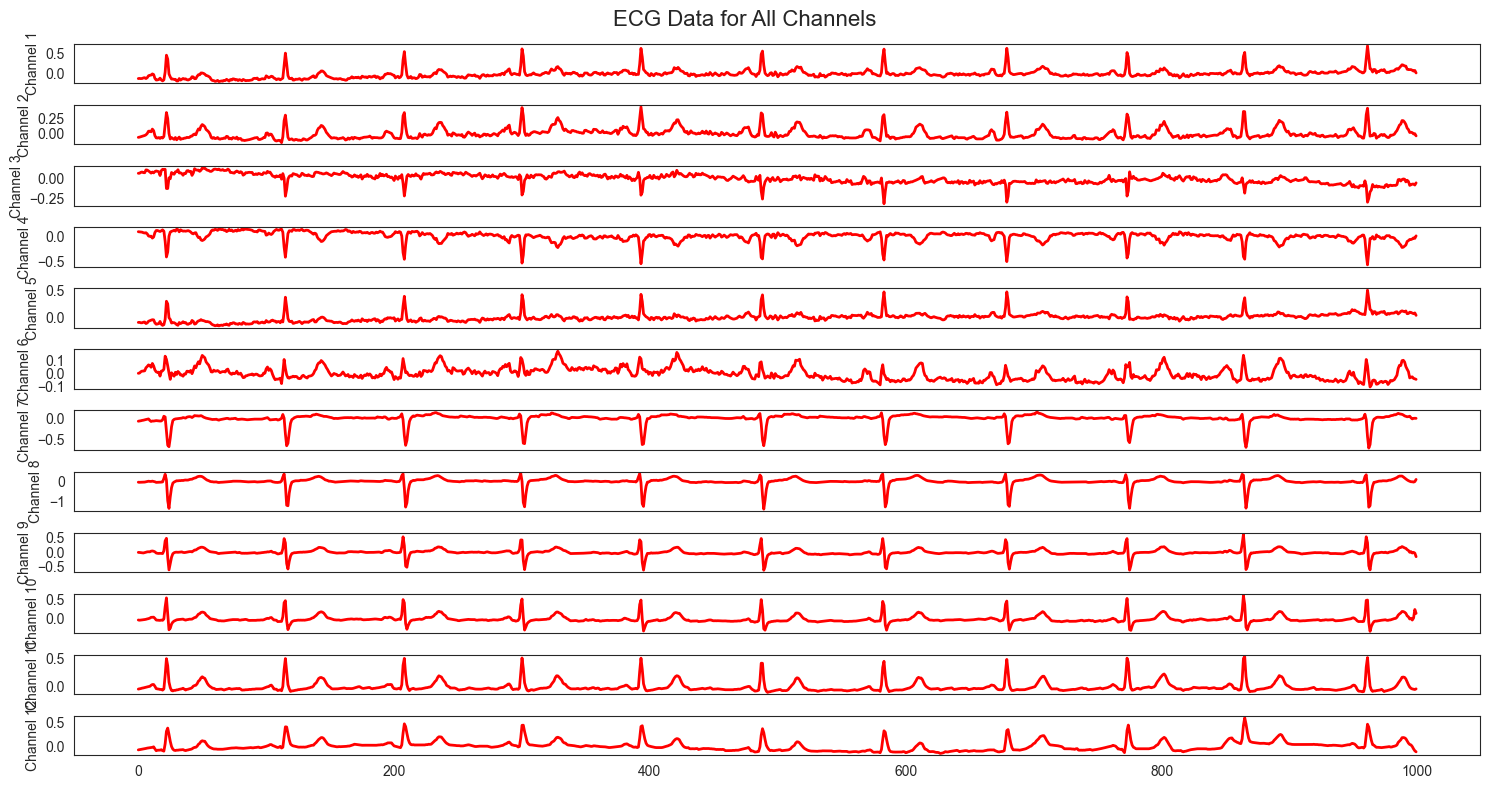

In [13]:
# Select a sample of ECG data (e.g., the first sample)
sample = ECG_data[0]

# Create subplots for each channel arranged vertically
fig, axes = plt.subplots(sample.shape[1], 1, figsize=(15, 8), sharex=True)

# Set a custom color palette (e.g., 'coolwarm')
sns.set_palette("coolwarm")

# Plot each channel separately in its own subplot
for i in range(sample.shape[1]):
    sns.lineplot(x=np.arange(sample.shape[0]), y=sample[:, i], ax=axes[i], linewidth=2, color='red')
    axes[i].set_ylabel(f"Channel {i+1}")

# Set a common title for all subplots (optional)
plt.suptitle("ECG Data for All Channels", fontsize=16)

# Adjust subplot layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()

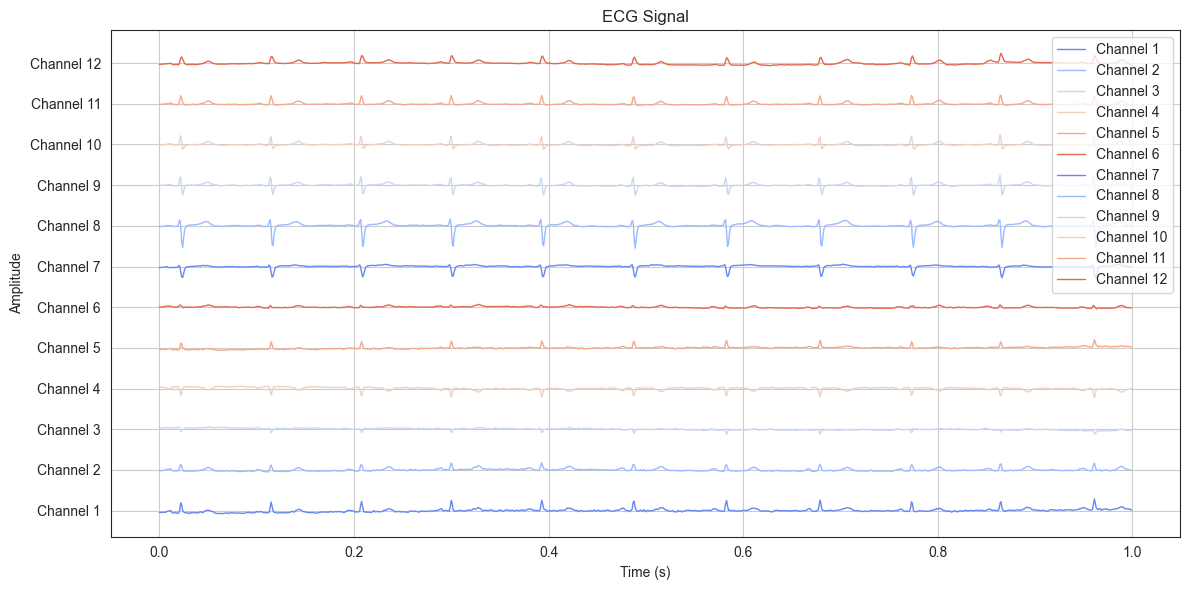

In [14]:
# Select a sample of ECG data (e.g., the first sample)
sample = ECG_data[0]

# Determine the number of channels
num_channels = sample.shape[1]

# Create a time vector based on the number of samples and the sampling rate (assuming 1000 Hz)
sampling_rate = 1000
duration = sample.shape[0] / sampling_rate
time = np.linspace(0, duration, sample.shape[0], endpoint=False)

# Create a single plot for all channels
plt.figure(figsize=(12, 6))

# Plot each channel on the same grid
for i in range(num_channels):
    offset = i * 2.5  # Vertical offset for each channel
    plt.plot(time, sample[:, i] + offset, label=f'Channel {i + 1}', linewidth=1)

# Set plot title, labels, and legend
plt.title('ECG Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()

# Adjust y-axis ticks and labels for channel separation
plt.yticks(np.arange(0, num_channels * 2.5, 2.5), [f'Channel {i + 1}' for i in range(num_channels)])

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

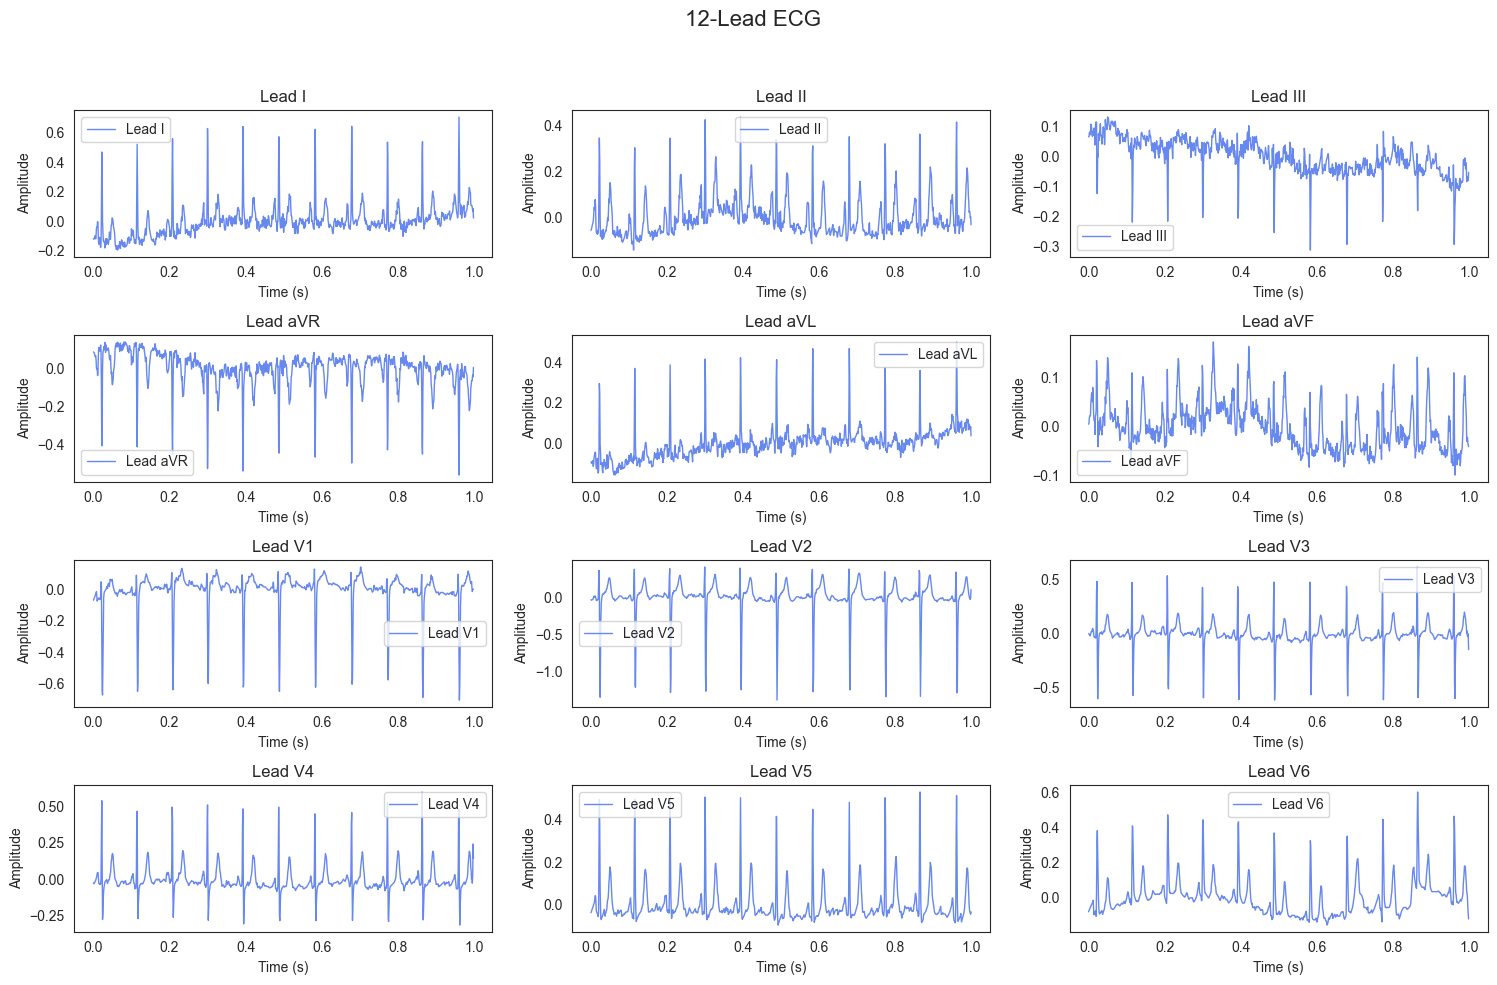

In [15]:
# Select a sample of ECG data (e.g., the first sample)
sample = ECG_data[0]

# Determine the number of channels (assuming a 12-lead ECG)
num_channels = 12

# Create a time vector based on the number of samples and the sampling rate (assuming 1000 Hz)
sampling_rate = 1000
duration = sample.shape[0] / sampling_rate
time = np.linspace(0, duration, sample.shape[0], endpoint=False)

# Define the layout for a standard 12-lead ECG
lead_names = [
    "I", "II", "III", "aVR", "aVL", "aVF",
    "V1", "V2", "V3", "V4", "V5", "V6"
]

# Create subplots for each lead in a 4x3 grid
fig, axes = plt.subplots(4, 3, figsize=(15, 10))
fig.suptitle("12-Lead ECG", fontsize=16)

# Plot each channel in the corresponding lead subplot
for i, lead_name in enumerate(lead_names):
    row = i // 3
    col = i % 3
    axes[row, col].plot(time, sample[:, i], label=f'Lead {lead_name}', linewidth=1)
    axes[row, col].set_title(f'Lead {lead_name}')
    axes[row, col].set_xlabel('Time (s)')
    axes[row, col].set_ylabel('Amplitude')
    axes[row, col].legend()

# Remove empty subplots (if any)
for i in range(num_channels, len(lead_names)):
    row = i // 3
    col = i % 3
    fig.delaxes(axes[row, col])

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plot
plt.show()


In [16]:
# Define the list of column names to drop from the DataFrame
columns_to_drop = [
    "validated_by_human",
    "site",
    "validated_by",
    "device",
    "recording_date",
    "report",
    "baseline_drift",
    "burst_noise",
    "electrodes_problems",
    "pacemaker",
    "heart_axis",
    "infarction_stadium1",
    "infarction_stadium2",
    "second_opinion",
    "initial_autogenerated_report",
    "extra_beats",
    "static_noise",
    "nurse"
    
]

# Drop the specified columns from the DataFrame
ecg_dataset = ecg_dataset.drop(columns_to_drop, axis='columns')




In [17]:
# Print the updated DataFrame
print(ecg_dataset)

        patient_id  age  sex  height  weight  \
ecg_id                                         
1            15709   56    1     NaN    63.0   
2            13243   19    0     NaN    70.0   
3            20372   37    1     NaN    69.0   
4            17014   24    0     NaN    82.0   
5            17448   19    1     NaN    70.0   
...            ...  ...  ...     ...     ...   
21833        17180   67    1     NaN     NaN   
21834        20703   93    0     NaN     NaN   
21835        19311   59    1     NaN     NaN   
21836         8873   64    1     NaN     NaN   
21837        11744   68    0     NaN     NaN   

                                                scp_codes  strat_fold  \
ecg_id                                                                  
1                {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}           3   
2                            {'NORM': 80.0, 'SBRAD': 0.0}           2   
3                              {'NORM': 100.0, 'SR': 0.0}           5   
4         

In [18]:
# Check the shape of the ecg_dataset dataframe
ecg_dataset_shape = ecg_dataset.shape

# Display the shape of the dataframe
print("Shape of the ECG Dataset:")
print(ecg_dataset_shape)

Shape of the ECG Dataset:
(21837, 10)


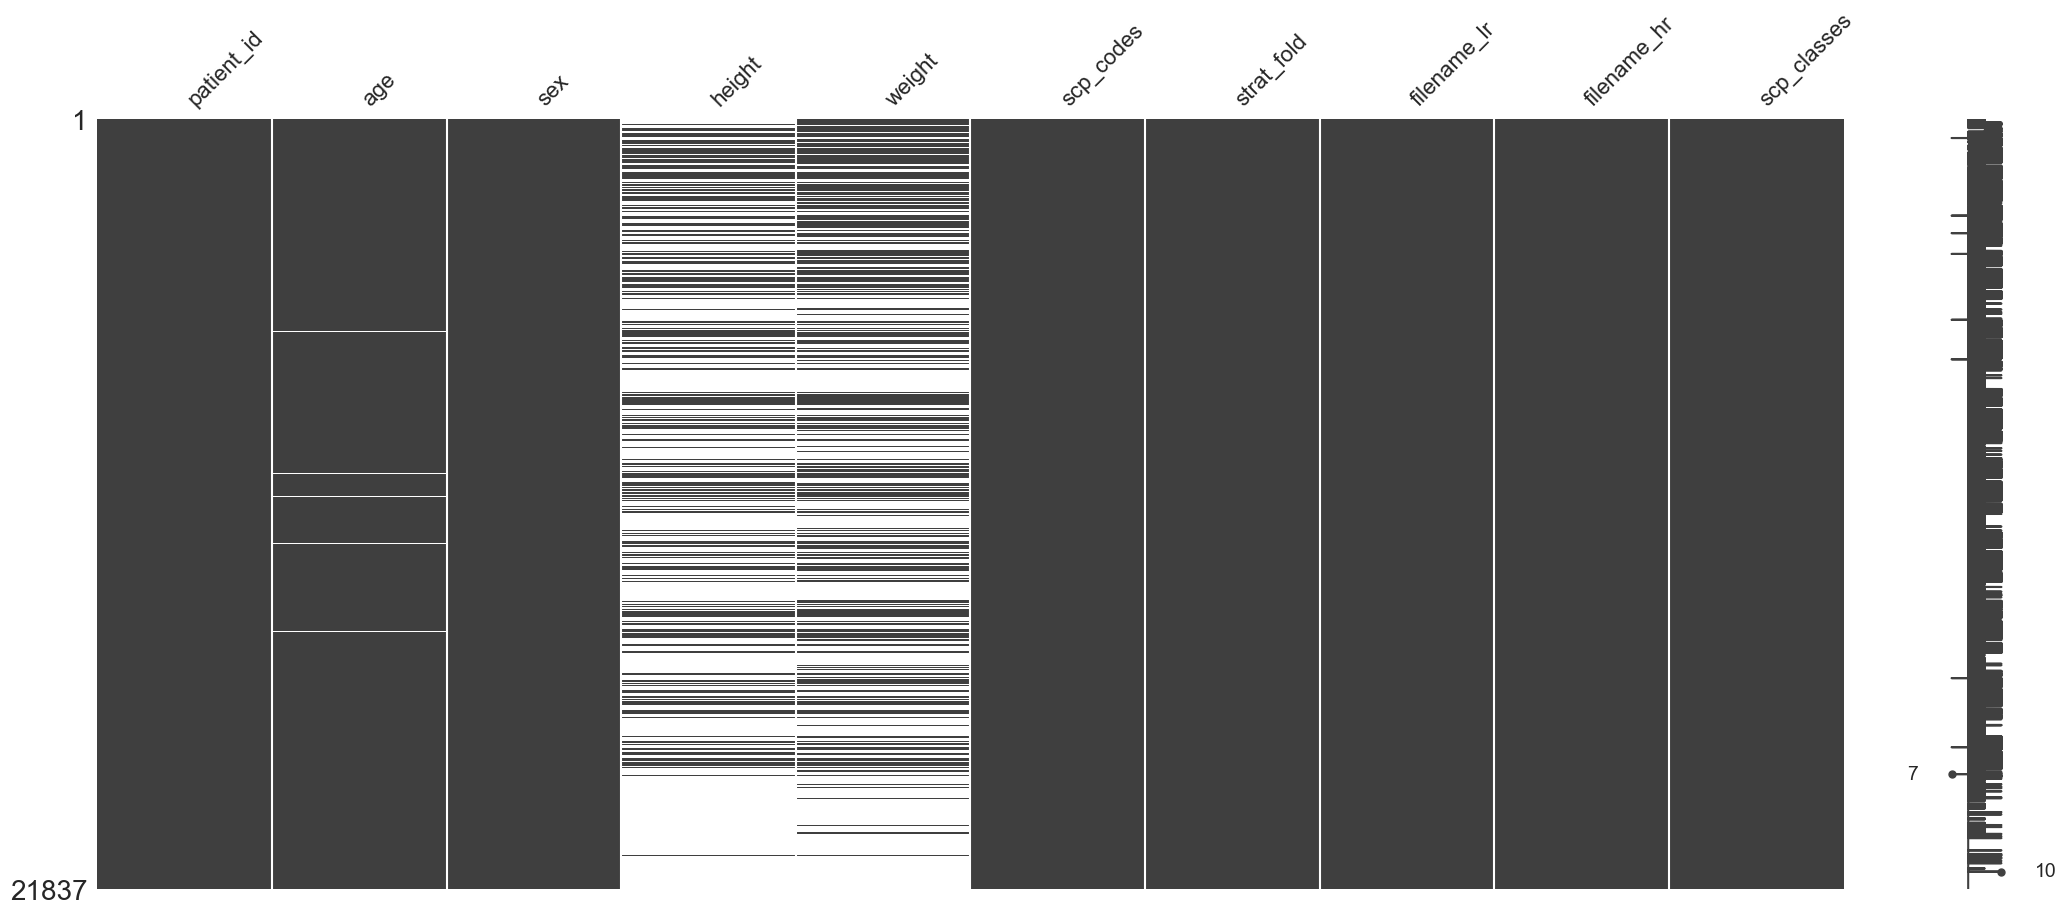

In [19]:
# Check for missing values in the ecg_dataset dataframe
msno.matrix(ecg_dataset)

# Display the matrix of missing values
plt.show()


In [20]:
# Select columns to view unique values, excluding 'scp_codes' and 'scp_classes'
columns_to_check = [col for col in ecg_dataset.columns if col not in ('scp_codes', 'scp_classes')]

# Calculate and display the number of unique values in each selected column
unique_value_counts = ecg_dataset[columns_to_check].nunique(dropna=True)

# Print the count of unique values for each column
print("Unique Value Counts in Selected Columns:")
print(unique_value_counts)

Unique Value Counts in Selected Columns:
patient_id     18885
age               94
sex                2
height            77
weight           127
strat_fold        10
filename_lr    21837
filename_hr    21837
dtype: int64


In [21]:
# Preprocessing data 
# The model input will ECG dataframe and ECG dataset 
# new datafrae will eb created corresponding to the diagnosis class 
# - X - prefix for patient and sample metadata
# - Y - prefix for ECG curves
# - Z - prefix for targets

# Create a new dataframe 'X' for patient and sample metadata
X = pd.DataFrame(index=ecg_dataset.index)

# Add patient age to 'X' and fill missing values with 0
X['age'] = ecg_dataset.age
X.age.fillna(0, inplace=True)

# Add patient sex to 'X' and convert it to float, fill missing values with 0
X['sex'] = ecg_dataset.sex.astype(float)
X.sex.fillna(0, inplace=True)


# Add patient weight to 'X' and fill missing values with 0
X['weight'] = ecg_dataset.weight
X.weight.fillna(0, inplace=True)

# Add patient height to 'X' and fill missing values with 0
X['height'] = ecg_dataset.height
X.height.fillna(0, inplace=True)


X

,age,sex,weight,height
ecg_id,,,,
1,56,1.0,63.0,0.0
2,19,0.0,70.0,0.0
3,37,1.0,69.0,0.0
4,24,0.0,82.0,0.0
5,19,1.0,70.0,0.0
...,...,...,...,...
21833,67,1.0,0.0,0.0
21834,93,0.0,0.0,0.0
21835,59,1.0,0.0,0.0


In [22]:
# Access and display the data for the first row (sample) in the ecg_dataset dataframe
first_sample_data = ecg_dataset.loc[ecg_dataset.index[0]]
print(first_sample_data)

patient_id                                        15709
age                                                  56
sex                                                   1
height                                              NaN
weight                                             63.0
scp_codes      {'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}
strat_fold                                            3
filename_lr                   records100/00000/00001_lr
filename_hr                   records500/00000/00001_hr
scp_classes                                      [NORM]
Name: 1, dtype: object


In [23]:
# Assign the variable 'Y' to the ECG signal data stored in 'ECG_data'
Y = ECG_data

In [24]:
# Create a new dataframe 'Z' with all values initialized to 0
Z = pd.DataFrame(0, index=ecg_dataset.index, columns=['NORM', 'MI', 'STTC', 'CD', 'HYP'], dtype='int')

# Iterate through each sample in 'ecg_dataset'
for i in Z.index:
    # Access the 'scp_classes' for the current sample and iterate through them
    for k in ecg_dataset.loc[i].scp_classes:
        # Set the corresponding class column to 1 in 'Z'
        Z.loc[i, k] = 1

Z


,NORM,MI,STTC,CD,HYP
ecg_id,,,,,
1,1,0,0,0,0
2,1,0,0,0,0
3,1,0,0,0,0
4,1,0,0,0,0
5,1,0,0,0,0
...,...,...,...,...,...
21833,0,0,1,0,0
21834,1,0,0,0,0
21835,0,0,1,0,0


# Data Splitting

In [25]:
# The code splits the data into three sets: training, validation, and test sets based on the 'strat_fold' values.
# Training set (strat_fold values less than or equal to 8)
X_train = X[ecg_dataset.strat_fold <= 8]
Y_train = ECG_data[X_train.index - 1]  # Subtract 1 from index to align with ECG_data
Z_train = Z[ecg_dataset.strat_fold <= 8]

# Validation set (strat_fold value equal to 9)
X_valid = X[ecg_dataset.strat_fold == 9]
Y_valid = ECG_data[X_valid.index - 1]  # Subtract 1 from index to align with ECG_data
Z_valid = Z[ecg_dataset.strat_fold == 9]

# Test set (strat_fold value equal to 10)
X_test = X[ecg_dataset.strat_fold == 10]
Y_test = ECG_data[X_test.index - 1]  # Subtract 1 from index to align with ECG_data
Z_test = Z[ecg_dataset.strat_fold == 10]


# Print the shapes of the resulting datasets
print("Shapes of Training Set:")
print(X_train.shape, Y_train.shape, Z_train.shape)
print("\nShapes of Validation Set:")
print(X_valid.shape, Y_valid.shape, Z_valid.shape)
print("\nShapes of Test Set:")
print(X_test.shape, Y_test.shape, Z_test.shape)

Shapes of Training Set:
(17441, 4) (17441, 1000, 12) (17441, 5)

Shapes of Validation Set:
(2193, 4) (2193, 1000, 12) (2193, 5)

Shapes of Test Set:
(2203, 4) (2203, 1000, 12) (2203, 5)


#  Data Normalization / Feature Scaling 

In [26]:
# Create a StandardScaler instance for feature scaling
X_scaler = StandardScaler()

# Fit the scaler on the training data and transform the datasets
X_train = pd.DataFrame(X_scaler.fit_transform(X_train), columns=X_train.columns)
X_valid = pd.DataFrame(X_scaler.transform(X_valid), columns=X_valid.columns)
X_test = pd.DataFrame(X_scaler.transform(X_test), columns=X_test.columns)



In [27]:
# Create a StandardScaler instance for feature scaling on the ECG data (Y)
Y_scaler = StandardScaler()

# Fit the scaler on the training ECG data
Y_scaler.fit(Y_train.reshape(-1, Y_train.shape[-1]))

# Transform the datasets using the fitted scaler
Y_train = Y_scaler.transform(Y_train.reshape(-1, Y_train.shape[-1])).reshape(Y_train.shape)
Y_valid = Y_scaler.transform(Y_valid.reshape(-1, Y_valid.shape[-1])).reshape(Y_valid.shape)
Y_test = Y_scaler.transform(Y_test.reshape(-1, Y_test.shape[-1])).reshape(Y_test.shape)

# Save the Preprocessed Dataset 

In [28]:
# Define the file name for saving the NumPy data file in the current directory
Preprocessed_dataset = 'Dataset.npz'

# Create a dictionary with data to be saved
save_args = {
    'X_train': X_train.to_numpy().astype('float32'),
    'X_valid': X_valid.to_numpy().astype('float32'),
    'X_test':  X_test.to_numpy().astype('float32'),
    'Y_train': Y_train.astype('float32'), 
    'Y_valid': Y_valid.astype('float32'),
    'Y_test':  Y_test.astype('float32'),
    'Z_train': Z_train.to_numpy().astype('float32'), 
    'Z_valid': Z_valid.to_numpy().astype('float32'),
    'Z_test':  Z_test.to_numpy().astype('float32'),
}

# Save the data in the current directory
np.savez(Preprocessed_dataset, **save_args)


In [29]:
# Read the Data from the saved file 
# Define the file name for reading the NumPy data file from the current directory
Preprocessed_dataset = 'Dataset.npz'

# Load the data from the current directory
with np.load(Preprocessed_dataset) as data:
    for k in data.keys():
        globals()[k] = data[k].astype(float)

# A baseline Naive Model(1)

In [30]:
# Calculates the binary classification accuracy between the true labelsand predicted labels. 
# All samples are from "NORM" class, Most repeated class. 

# Create a numpy array 'z1' filled with zeros and one-hot encode the first class
z1 = np.zeros(Z_test.shape)
z1[:, 0] = 1

# Create a BinaryAccuracy metric instance
m = keras.metrics.BinaryAccuracy()

# Update the metric state with the true labels (Z_test) and predicted labels (z1)
m.update_state(Z_test, z1)

# Calculate and retrieve the result of the BinaryAccuracy metric
result = m.result()

# Naive Model(2)

In [31]:
# Calculate the class probabilities based on the training data
z_prob = Z_train.sum(axis=0) / Z_train.shape[0]

# Generate random samples for testing
z2 = np.random.uniform(size=Z_test.shape)

# Compare the random samples with class probabilities to create binary predictions
for i in range(z2.shape[-1]):
    z2[:, i] = (z2[:, i] < z_prob[i]).astype('float64')

# Create a BinaryAccuracy metric instance
m = keras.metrics.BinaryAccuracy()

# Update the metric state with the true labels (Z_test) and predicted labels (z2)
m.update_state(Z_test, z2)

# Calculate and retrieve the result of the BinaryAccuracy metric
result = m.result()
result

<tf.Tensor: shape=(), dtype=float32, numpy=0.6462097>

# X model 

In [32]:
# Define a function to create a classifier model using the X dataset
def X_classifier(X, *, units=32, dropouts=0.3):
 # Add a dense hidden layer with ReLU activation
    X = keras.layers.Dense(units, activation='relu', name='X_dense_1')(X)

    # Apply dropout regularization
    X = keras.layers.Dropout(dropouts, name='X_drop_1')(X)

    # Add another dense hidden layer with ReLU activation
    X = keras.layers.Dense(units, activation='relu', name='X_dense_2')(X)

    # Apply dropout regularization
    X = keras.layers.Dropout(dropouts, name='X_drop_2')(X)

    return X


# Model (1)

In [33]:
# Fully Connected Neural Network with Dropout Regularization and Dense layers with sigomid function
def create_model1(X, Z_shape):
   # Define the input layer for X
    X_inputs = keras.Input(shape=X[1:], name='X_inputs')

    # Create the X model using the defined function
    X_model = X_classifier(X_inputs)

    # Add additional hidden layers for Z prediction
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_1')(X_model)
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_2')(X)
    X = keras.layers.Dropout(0.5, name='Z_drop_1')(X)

    # Output layer for Z with sigmoid activation
    outputs = keras.layers.Dense(Z_shape[-1], activation='sigmoid', name='Z_outputs')(X)

    # Create the final model with inputs and outputs
    model = keras.Model(inputs=X_inputs, outputs=outputs, name='model01')

    return model

In [34]:
# Create the model and compile it

# Create the model using the 'create_model01' function
model_1 = create_model1(X_train.shape, Z_train.shape)  # Pass X_train as input data, not its shape

# Compile the model with optimizer, loss function, and evaluation metrics
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy', 'Precision', 'Recall'])

# Display the summary of the model architecture
model_1.summary()

Model: "model01"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 X_inputs (InputLayer)       [(None, 4)]               0         
                                                                 
 X_dense_1 (Dense)           (None, 32)                160       
                                                                 
 X_drop_1 (Dropout)          (None, 32)                0         
                                                                 
 X_dense_2 (Dense)           (None, 32)                1056      
                                                                 
 X_drop_2 (Dropout)          (None, 32)                0         
                                                                 
 Z_dense_1 (Dense)           (None, 64)                2112      
                                                                 
 Z_dense_2 (Dense)           (None, 64)                4160

In [35]:
# Specify the path where you want to save the model architecture as a picture
save_path = 'model01_architecture.png'

# Plot and save the model architecture as a picture
plot_model(model_1, to_file=save_path, show_shapes=True, show_layer_names=True)

print("Model architecture saved as:", save_path)

Model architecture saved as: model01_architecture.png


In [36]:
# Model fitting using check point to return the best results 

checkpoint_path = "checkpoints_1/model01.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', patience=10),
    keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, verbose=1, save_best_only=True)
]

history = model_1.fit(X_train, Z_train, epochs=40, batch_size=32, callbacks=callbacks_list, validation_data=(X_valid, Z_valid))

#model_1 = keras.models.load_model(MODEL_CHECKPOINT)

Epoch 1/40
541/546 [============================>.] - ETA: 0s - loss: 0.5302 - binary_accuracy: 0.7604 - precision: 0.6042 - recall: 0.1729
Epoch 1: val_loss improved from inf to 0.50202, saving model to checkpoints_1/model01.ckpt
INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


546/546 [==============================] - 5s 6ms/step - loss: 0.5302 - binary_accuracy: 0.7604 - precision: 0.6044 - recall: 0.1728 - val_loss: 0.5020 - val_binary_accuracy: 0.7720 - val_precision: 0.6797 - val_recall: 0.2044
Epoch 2/40
539/546 [============================>.] - ETA: 0s - loss: 0.5114 - binary_accuracy: 0.7708 - precision: 0.6938 - recall: 0.1802
Epoch 2: val_loss improved from 0.50202 to 0.50062, saving model to checkpoints_1/model01.ckpt
INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


546/546 [==============================] - 2s 5ms/step - loss: 0.5114 - binary_accuracy: 0.7708 - precision: 0.6940 - recall: 0.1801 - val_loss: 0.5006 - val_binary_accuracy: 0.7718 - val_precision: 0.6884 - val_recall: 0.1962
Epoch 3/40
535/546 [============================>.] - ETA: 0s - loss: 0.5070 - binary_accuracy: 0.7720 - precision: 0.6983 - recall: 0.1853
Epoch 3: val_loss did not improve from 0.50062
546/546 [==============================] - 1s 3ms/step - loss: 0.5070 - binary_accuracy: 0.7719 - precision: 0.6979 - recall: 0.1851 - val_loss: 0.5014 - val_binary_accuracy: 0.7726 - val_precision: 0.7061 - val_recall: 0.1894
Epoch 4/40
531/546 [============================>.] - ETA: 0s - loss: 0.5040 - binary_accuracy: 0.7730 - precision: 0.7030 - recall: 0.1873
Epoch 4: val_loss improved from 0.50062 to 0.50002, saving model to checkpoints_1/model01.ckpt
INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


...

546/546 [==============================] - 2s 4ms/step - loss: 0.4998 - binary_accuracy: 0.7725 - precision: 0.7016 - recall: 0.1868 - val_loss: 0.4938 - val_binary_accuracy: 0.7736 - val_precision: 0.7055 - val_recall: 0.1966
Epoch 14/40
533/546 [============================>.] - ETA: 0s - loss: 0.4988 - binary_accuracy: 0.7728 - precision: 0.7012 - recall: 0.1896
Epoch 14: val_loss did not improve from 0.49384
546/546 [==============================] - 2s 3ms/step - loss: 0.4987 - binary_accuracy: 0.7729 - precision: 0.7015 - recall: 0.1897 - val_loss: 0.4939 - val_binary_accuracy: 0.7721 - val_precision: 0.7203 - val_recall: 0.1773
Epoch 15/40
546/546 [==============================] - ETA: 0s - loss: 0.4981 - binary_accuracy: 0.7732 - precision: 0.7021 - recall: 0.1907
Epoch 15: val_loss improved from 0.49384 to 0.49335, saving model to checkpoints_1/model01.ckpt
INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


546/546 [==============================] - 4s 7ms/step - loss: 0.4981 - binary_accuracy: 0.7732 - precision: 0.7021 - recall: 0.1907 - val_loss: 0.4934 - val_binary_accuracy: 0.7737 - val_precision: 0.7069 - val_recall: 0.1962
Epoch 16/40
531/546 [============================>.] - ETA: 0s - loss: 0.4982 - binary_accuracy: 0.7723 - precision: 0.7056 - recall: 0.1834
Epoch 16: val_loss did not improve from 0.49335
546/546 [==============================] - 3s 5ms/step - loss: 0.4978 - binary_accuracy: 0.7726 - precision: 0.7058 - recall: 0.1847 - val_loss: 0.4949 - val_binary_accuracy: 0.7734 - val_precision: 0.6795 - val_recall: 0.2148
Epoch 17/40
542/546 [============================>.] - ETA: 0s - loss: 0.4979 - binary_accuracy: 0.7729 - precision: 0.7039 - recall: 0.1880
Epoch 17: val_loss did not improve from 0.49335
546/546 [==============================] - 2s 4ms/step - loss: 0.4978 - binary_accuracy: 0.7730 - precision: 0.7040 - recall: 0.1881 - val_loss: 0.4946 - val_binary_acc

INFO:tensorflow:Assets written to: checkpoints_1/model01.ckpt/assets


546/546 [==============================] - 4s 8ms/step - loss: 0.4975 - binary_accuracy: 0.7736 - precision: 0.7131 - recall: 0.1870 - val_loss: 0.4933 - val_binary_accuracy: 0.7747 - val_precision: 0.7094 - val_recall: 0.2012
Epoch 20/40
543/546 [============================>.] - ETA: 0s - loss: 0.4982 - binary_accuracy: 0.7730 - precision: 0.7049 - recall: 0.1879
Epoch 20: val_loss did not improve from 0.49333
546/546 [==============================] - 3s 5ms/step - loss: 0.4982 - binary_accuracy: 0.7730 - precision: 0.7051 - recall: 0.1878 - val_loss: 0.4934 - val_binary_accuracy: 0.7729 - val_precision: 0.6984 - val_recall: 0.1966
Epoch 21/40
546/546 [==============================] - ETA: 0s - loss: 0.4971 - binary_accuracy: 0.7737 - precision: 0.7192 - recall: 0.1837
Epoch 21: val_loss did not improve from 0.49333
546/546 [==============================] - 3s 5ms/step - loss: 0.4971 - binary_accuracy: 0.7737 - precision: 0.7192 - recall: 0.1837 - val_loss: 0.4938 - val_binary_acc

In [37]:
# Create an instance of the model and Load the weights from the checkpoint file
model_1 = keras.models.load_model("checkpoints_1/model01.ckpt")

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


<Figure size 1000x600 with 0 Axes>

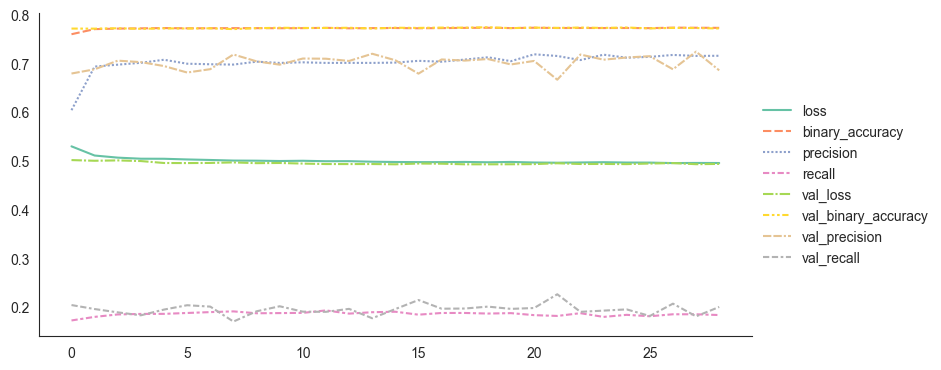

In [38]:
# Performance Metrics 
# Create a line plot to visualize training history

custom_palette = sns.color_palette("Set2")
plt.figure(figsize=(10, 6))

sns.relplot(data=pd.DataFrame(history.history), kind='line', height=4, aspect=2, palette=custom_palette)
plt.show()

In [39]:
# Evaluate the model using the test dataset 
evaluation_results = model_1.evaluate(X_test, Z_test)


69/69 [==============================] - 0s 2ms/step - loss: 0.4921 - binary_accuracy: 0.7746 - precision: 0.7137 - recall: 0.1896


# Y Model 

In [40]:
# This function will create Y model 
# 1D Covolutional neural network for ECG charts with Max pool layer to reduce timeseries dimension 

# Define a function to create the Y (ECG data) model
def create_Y_model(X, *, filters=(32, 64, 128), kernel_size=(5, 3, 3), strides=(1, 1, 1)):
    # Extract filter sizes
    f1, f2, f3 = filters
    # Extract kernel sizes
    k1, k2, k3 = kernel_size
    # Extract stride sizes
    s1, s2, s3 = strides
    # First convolutional layer
    X = keras.layers.Conv1D(f1, k1, strides=s1, padding='same', name='Y_conv_1')(X)
    # Batch normalization for stability
    X = keras.layers.BatchNormalization(name='Y_norm_1')(X)
    # ReLU activation function for non-linearity
    X = keras.layers.ReLU(name='Y_relu_1')(X) 
    # Max pooling to reduce dimensionality
    X = keras.layers.MaxPool1D(2, name='Y_pool_1')(X) 
    # Second convolutional layer
    X = keras.layers.Conv1D(f2, k2, strides=s2, padding='same', name='Y_conv_2')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_2')(X)
    X = keras.layers.ReLU(name='Y_relu_2')(X)
    X = keras.layers.MaxPool1D(2, name='Y_pool_2')(X)
    # Third convolutional layer
    X = keras.layers.Conv1D(f3, k3, strides=s3, padding='same', name='Y_conv_3')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_3')(X)
    X = keras.layers.ReLU(name='Y_relu_3')(X)
    # Global Average Pooling
    X = keras.layers.GlobalAveragePooling1D(name='Y_aver')(X)
    # Dropout layer for regularization
    X = keras.layers.Dropout(0.5, name='Y_drop')(X)

    return X


# Model 2 (used in the application)


In [41]:
# Define a function takes two datasets X and Y and produce an output in the Z dataset.
# each dataset will be classified using different models and their results will be fed to two fully connedcted dense layer
def create_model02(X_shape, Y_shape, Z_shape):
     # Input layers for X and Y datasets
    X_inputs = keras.Input(X_shape[1:], name='X_inputs')
    Y_inputs = keras.Input(Y_shape[1:], name='Y_inputs')
    # Combine the outputs of two different models:
    # 1. X_classifier for the X dataset
    # 2. create_Y_model for the Y dataset
    X = keras.layers.Concatenate(name='Z_concat')([X_classifier(X_inputs), create_Y_model(Y_inputs, filters=(64, 128, 256), kernel_size=(7, 3, 3))])
    # Two fully connected Dense layers for feature fusion
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_1')(X)
    X = keras.layers.Dense(64, activation='relu', name='Z_dense_2')(X)
     # Dropout layer for regularization
    X = keras.layers.Dropout(0.5, name='Z_drop_1')(X)
    # Final Dense layer with sigmoid activation for the output
    outputs = keras.layers.Dense(Z_shape[-1], activation='sigmoid', name='Z_outputs')(X)
     # Create Model 2 with inputs and output
    model = keras.Model(inputs=[X_inputs, Y_inputs], outputs=outputs, name='model02')
    return model

In [42]:
# Create Model 2 using the defined function
model02 = create_model02(X_train.shape, Y_train.shape, Z_train.shape)
# Compile Model 2 with the specified optimizer, loss function, and metrics
model02.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy', 'Precision', 'Recall'])
# Display a summary of Model 2's architecture
model02.summary()

Model: "model02"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Y_inputs (InputLayer)       [(None, 1000, 12)]           0         []                            
                                                                                                  
 Y_conv_1 (Conv1D)           (None, 1000, 64)             5440      ['Y_inputs[0][0]']            
                                                                                                  
 Y_norm_1 (BatchNormalizati  (None, 1000, 64)             256       ['Y_conv_1[0][0]']            
 on)                                                                                              
                                                                                                  
 Y_relu_1 (ReLU)             (None, 1000, 64)             0         ['Y_norm_1[0][0]']      

In [43]:
# Specify the path where you want to save the model architecture as a picture
save_path = 'model02_architecture.png'

# Plot and save the model architecture as a picture
plot_model(model02, to_file=save_path, show_shapes=True, show_layer_names=True)

print("Model architecture saved as:", save_path)

Model architecture saved as: model02_architecture.png


In [44]:
# Define the checkpoint path and directory
checkpoint_path = "checkpoints_1/model02.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Define a list of callbacks, including early stopping and model checkpoint
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', patience=20),
    keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True)
]

# Fit Model 3 with training data
history = model02.fit([X_train, Y_train], Z_train, epochs=100, batch_size=32, validation_data=([X_valid, Y_valid], Z_valid), callbacks=callbacks_list)


Epoch 1/100
545/546 [============================>.] - ETA: 0s - loss: 0.4240 - binary_accuracy: 0.8101 - precision: 0.6745 - recall: 0.4921INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


546/546 [==============================] - 149s 265ms/step - loss: 0.4240 - binary_accuracy: 0.8101 - precision: 0.6745 - recall: 0.4921 - val_loss: 0.3558 - val_binary_accuracy: 0.8467 - val_precision: 0.7557 - val_recall: 0.5915
Epoch 2/100
545/546 [============================>.] - ETA: 0s - loss: 0.3664 - binary_accuracy: 0.8437 - precision: 0.7375 - recall: 0.6005INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


546/546 [==============================] - 172s 315ms/step - loss: 0.3664 - binary_accuracy: 0.8437 - precision: 0.7375 - recall: 0.6004 - val_loss: 0.3346 - val_binary_accuracy: 0.8518 - val_precision: 0.7469 - val_recall: 0.6357
Epoch 3/100
545/546 [============================>.] - ETA: 0s - loss: 0.3416 - binary_accuracy: 0.8578 - precision: 0.7670 - recall: 0.6350INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


...

546/546 [==============================] - 160s 293ms/step - loss: 0.2465 - binary_accuracy: 0.9012 - precision: 0.8464 - recall: 0.7481 - val_loss: 0.2773 - val_binary_accuracy: 0.8894 - val_precision: 0.8062 - val_recall: 0.7467
Epoch 34/100
546/546 [==============================] - 139s 255ms/step - loss: 0.2441 - binary_accuracy: 0.9020 - precision: 0.8490 - recall: 0.7485 - val_loss: 0.2795 - val_binary_accuracy: 0.8868 - val_precision: 0.8097 - val_recall: 0.7285
Epoch 35/100
546/546 [==============================] - 240s 440ms/step - loss: 0.2459 - binary_accuracy: 0.9016 - precision: 0.8477 - recall: 0.7484 - val_loss: 0.2867 - val_binary_accuracy: 0.8862 - val_precision: 0.8119 - val_recall: 0.7221
Epoch 36/100
546/546 [==============================] - 135s 246ms/step - loss: 0.2425 - binary_accuracy: 0.9036 - precision: 0.8509 - recall: 0.7537 - val_loss: 0.2848 - val_binary_accuracy: 0.8857 - val_precision: 0.8090 - val_recall: 0.7239
Epoch 37/100
545/546 [===============

INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


546/546 [==============================] - 175s 321ms/step - loss: 0.2408 - binary_accuracy: 0.9033 - precision: 0.8507 - recall: 0.7526 - val_loss: 0.2763 - val_binary_accuracy: 0.8896 - val_precision: 0.8097 - val_recall: 0.7424
Epoch 38/100
546/546 [==============================] - 175s 320ms/step - loss: 0.2384 - binary_accuracy: 0.9051 - precision: 0.8554 - recall: 0.7555 - val_loss: 0.2753 - val_binary_accuracy: 0.8847 - val_precision: 0.8192 - val_recall: 0.7046
Epoch 39/100
545/546 [============================>.] - ETA: 0s - loss: 0.2397 - binary_accuracy: 0.9046 - precision: 0.8523 - recall: 0.7568INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model02.ckpt/assets


546/546 [==============================] - 141s 258ms/step - loss: 0.2397 - binary_accuracy: 0.9046 - precision: 0.8523 - recall: 0.7567 - val_loss: 0.2759 - val_binary_accuracy: 0.8914 - val_precision: 0.8065 - val_recall: 0.7567
Epoch 40/100
546/546 [==============================] - 165s 301ms/step - loss: 0.2393 - binary_accuracy: 0.9044 - precision: 0.8519 - recall: 0.7565 - val_loss: 0.2884 - val_binary_accuracy: 0.8845 - val_precision: 0.8127 - val_recall: 0.7121
Epoch 41/100
546/546 [==============================] - 132s 241ms/step - loss: 0.2369 - binary_accuracy: 0.9052 - precision: 0.8542 - recall: 0.7572 - val_loss: 0.2872 - val_binary_accuracy: 0.8847 - val_precision: 0.8019 - val_recall: 0.7292
Epoch 42/100
546/546 [==============================] - 144s 263ms/step - loss: 0.2346 - binary_accuracy: 0.9060 - precision: 0.8565 - recall: 0.7582 - val_loss: 0.2812 - val_binary_accuracy: 0.8866 - val_precision: 0.8128 - val_recall: 0.7232
Epoch 43/100
546/546 [===============

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


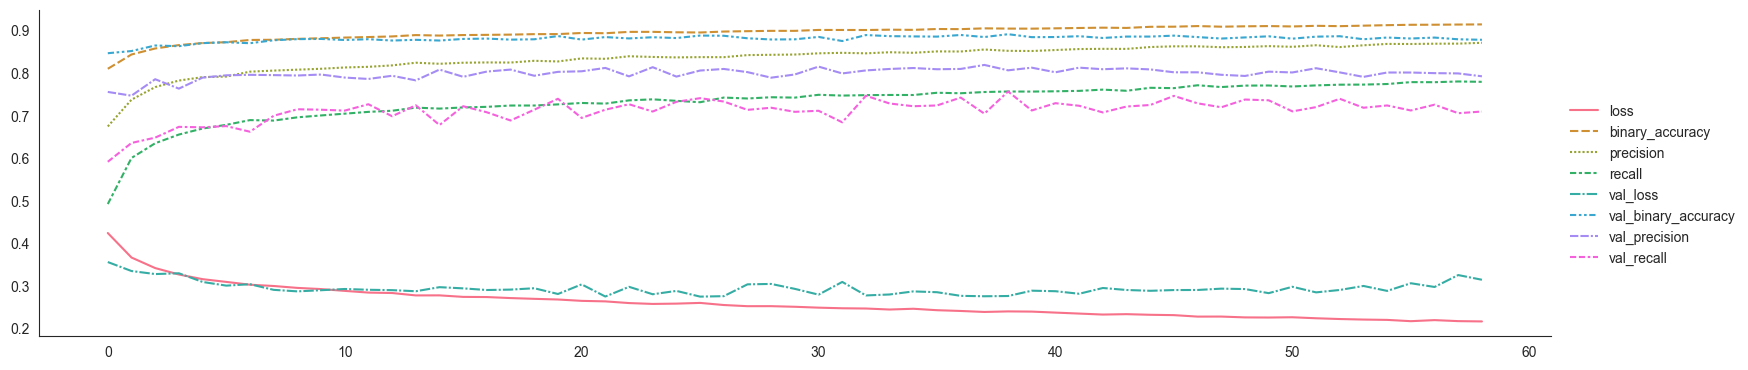

In [45]:
# Create a line plot using Seaborn's relplot
sns.relplot(data=pd.DataFrame(history.history), kind='line', height=4, aspect=4)
# Show the plot
plt.show()

In [46]:
# Evaluate Model 2 on test data
evaluation_results = model02.evaluate([X_test, Y_test], Z_test)
# The evaluation_results variable now contains the evaluation metrics such as loss and any specified metrics like accuracy, precision, and recall.


69/69 [==============================] - 3s 41ms/step - loss: 0.3129 - binary_accuracy: 0.8793 - precision: 0.7928 - recall: 0.7115


# Data Augmentation 

In [47]:
# defining an AugmentedDataGenerator class for generating augmented data by adding noise and creating sliding windows with random shifting
# Function to create sliding windows in data
# The sliding_window function is used to create sliding windows in the data with optional random shifting.
def sliding_window(x, size, shift):
    if 0 < size < x.shape[0]:
        shift = np.random.randint(0, x.shape[0] - size) if shift < 0 else shift
        return x[shift:size+shift, :]
    else:
        return x
    
# Define an AugmentedDataGenerator class as a keras.utils.Sequence
class AugmentedDataGenerator(keras.utils.Sequence):
    # Set the parameters to control the augmentation process
    def __init__(self, x, y, z, batch_size=32, window_size=0, window_shift=0, sigma=0.0, **kwargs):
        super(AugmentedDataGenerator, self).__init__(**kwargs)
        self.x = x
        self.y = y
        self.z = z
        self.batch_size = batch_size
        self.window_size = window_size
        self.window_shift = window_shift
        self.sigma = sigma

    @property
    def x_shape(self):
        return (self.batch_size, ) + self.x.shape[1:]

    @property
    def y_shape(self):
        return (self.batch_size, self.window_size if self.window_size > 0 else self.y.shape[1], ) + self.y.shape[2:]
    # The __len__ method defines the number of batches in the generator.
    @property
    def z_shape(self):
        return (self.batch_size, ) + self.z.shape[1:]

    def __len__(self):
        return math.ceil(len(self.y) / self.batch_size)
    # The __getitem__ method generates a batch of data. It slices the input data into batches and applies noise (if sigma > 0) to the generated windows.
    def __getitem__(self, idx):
        batch_x = self.x[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_y = np.array([sliding_window(r, self.window_size, self.window_shift) for r in self.y[idx * self.batch_size:(idx + 1) * self.batch_size]])
        batch_z = self.z[idx * self.batch_size:(idx + 1) * self.batch_size]
        
        if self.sigma > 0:
            batch_y += np.random.normal(loc=0.0, scale=self.sigma, size=batch_y.shape)
            
        return (batch_x, batch_y), batch_z

In [48]:
# Create generator instances for each dataset
# Training data generator with augmentation
train_gen = AugmentedDataGenerator(X_train, Y_train, Z_train, window_size=800, window_shift=-1, sigma=0.05)
# Validation data generator without augmentation
# window_size: 800
valid_gen = AugmentedDataGenerator(X_valid, Y_valid, Z_valid, window_size=800)
# Test data generator without augmentation
# window_size: 800
test_gen  = AugmentedDataGenerator(X_test, Y_test, Z_test, window_size=800)

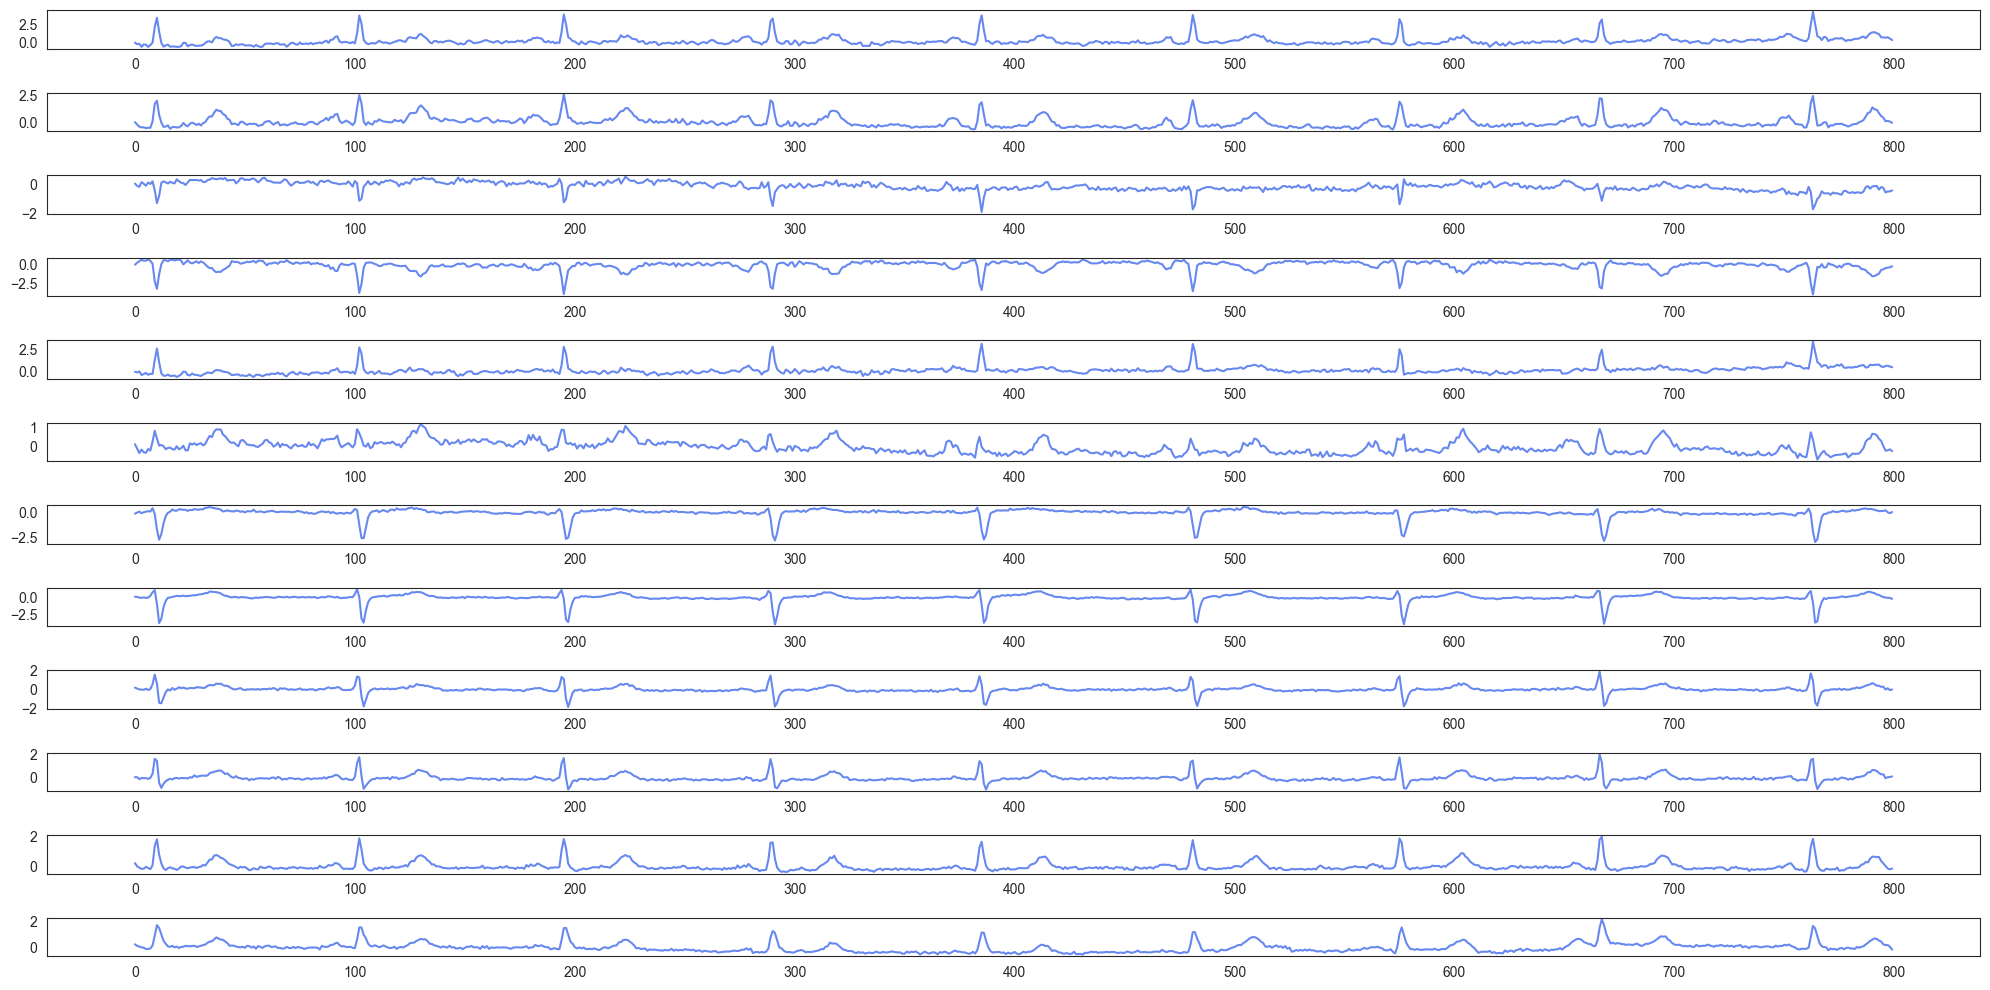

In [49]:
# Example of an augmented ECG sample
# Get a batch from the training generator (x, y) and corresponding labels z
(x, y), z = train_gen[0]
# Select an example augmented ECG window from the batch
sample = y[0]
# Create subplots to display each channel of the ECG
bar, axes = plt.subplots(sample.shape[1], 1, figsize=(20,10))
# Plot each channel of the ECG
for i in range(sample.shape[1]):
    sns.lineplot(x=np.arange(sample.shape[0]), y=sample[:, i], ax=axes[i])
# Adjust subplot layout for better visualization
plt.tight_layout()
# Show the plot
plt.show()

# Model (3) Using The Augmented Datasets

In [50]:
# Create Model 3 using the same function as Model 2
model03 = create_model02(train_gen.x_shape, train_gen.y_shape, train_gen.z_shape)
# Compile Model 3 with specified optimizer, loss function, and metrics
model03.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy', 'Precision', 'Recall'])
# Display a summary of Model 3's architecture
model03.summary()

Model: "model02"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 Y_inputs (InputLayer)       [(None, 800, 12)]            0         []                            
                                                                                                  
 Y_conv_1 (Conv1D)           (None, 800, 64)              5440      ['Y_inputs[0][0]']            
                                                                                                  
 Y_norm_1 (BatchNormalizati  (None, 800, 64)              256       ['Y_conv_1[0][0]']            
 on)                                                                                              
                                                                                                  
 Y_relu_1 (ReLU)             (None, 800, 64)              0         ['Y_norm_1[0][0]']      

In [51]:
# Define the checkpoint path and directory
checkpoint_path = "checkpoints_1/model03.ckpt"
checkpoint_dir = os.path.dirname(checkpoint_path)

# Define a list of callbacks, including early stopping and model checkpoint
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', patience=20),
    keras.callbacks.ModelCheckpoint(filepath=checkpoint_path, monitor='val_binary_accuracy', save_best_only=True)
]

# Fit Model 4 using the training generator, specifying callbacks and validation generator
history = model03.fit(train_gen, epochs=100, batch_size=32, callbacks=callbacks_list, validation_data=valid_gen)



Epoch 1/100
546/546 [==============================] - ETA: 0s - loss: 0.4405 - binary_accuracy: 0.8001 - precision: 0.6463 - recall: 0.4760INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


546/546 [==============================] - 127s 225ms/step - loss: 0.4405 - binary_accuracy: 0.8001 - precision: 0.6463 - recall: 0.4760 - val_loss: 0.3580 - val_binary_accuracy: 0.8440 - val_precision: 0.7394 - val_recall: 0.6022
Epoch 2/100
546/546 [==============================] - ETA: 0s - loss: 0.3704 - binary_accuracy: 0.8417 - precision: 0.7326 - recall: 0.5966 INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


546/546 [==============================] - 8093s 15s/step - loss: 0.3704 - binary_accuracy: 0.8417 - precision: 0.7326 - recall: 0.5966 - val_loss: 0.3483 - val_binary_accuracy: 0.8516 - val_precision: 0.7311 - val_recall: 0.6636
Epoch 3/100
546/546 [==============================] - ETA: 0s - loss: 0.3455 - binary_accuracy: 0.8560 - precision: 0.7603 - recall: 0.6352INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


...

546/546 [==============================] - 157s 287ms/step - loss: 0.2538 - binary_accuracy: 0.9001 - precision: 0.8423 - recall: 0.7480 - val_loss: 0.2955 - val_binary_accuracy: 0.8842 - val_precision: 0.8115 - val_recall: 0.7125
Epoch 28/100
546/546 [==============================] - ETA: 0s - loss: 0.2496 - binary_accuracy: 0.9009 - precision: 0.8455 - recall: 0.7479INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


546/546 [==============================] - 137s 252ms/step - loss: 0.2496 - binary_accuracy: 0.9009 - precision: 0.8455 - recall: 0.7479 - val_loss: 0.2834 - val_binary_accuracy: 0.8861 - val_precision: 0.8103 - val_recall: 0.7239
Epoch 29/100
546/546 [==============================] - 150s 275ms/step - loss: 0.2503 - binary_accuracy: 0.9001 - precision: 0.8428 - recall: 0.7472 - val_loss: 0.2866 - val_binary_accuracy: 0.8819 - val_precision: 0.8016 - val_recall: 0.7149
Epoch 30/100
546/546 [==============================] - 154s 282ms/step - loss: 0.2468 - binary_accuracy: 0.9020 - precision: 0.8460 - recall: 0.7523 - val_loss: 0.2790 - val_binary_accuracy: 0.8832 - val_precision: 0.8049 - val_recall: 0.7167
Epoch 31/100
546/546 [==============================] - ETA: 0s - loss: 0.2439 - binary_accuracy: 0.9036 - precision: 0.8472 - recall: 0.7585INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


INFO:tensorflow:Assets written to: checkpoints_1/model03.ckpt/assets


546/546 [==============================] - 154s 282ms/step - loss: 0.2439 - binary_accuracy: 0.9036 - precision: 0.8472 - recall: 0.7585 - val_loss: 0.2741 - val_binary_accuracy: 0.8892 - val_precision: 0.8106 - val_recall: 0.7392
Epoch 32/100
546/546 [==============================] - 164s 300ms/step - loss: 0.2441 - binary_accuracy: 0.9028 - precision: 0.8493 - recall: 0.7521 - val_loss: 0.2783 - val_binary_accuracy: 0.8845 - val_precision: 0.7964 - val_recall: 0.7367
Epoch 33/100
546/546 [==============================] - 156s 286ms/step - loss: 0.2431 - binary_accuracy: 0.9033 - precision: 0.8486 - recall: 0.7552 - val_loss: 0.2962 - val_binary_accuracy: 0.8775 - val_precision: 0.7999 - val_recall: 0.6946
Epoch 34/100
546/546 [==============================] - 179s 327ms/step - loss: 0.2413 - binary_accuracy: 0.9029 - precision: 0.8480 - recall: 0.7542 - val_loss: 0.2866 - val_binary_accuracy: 0.8812 - val_precision: 0.7921 - val_recall: 0.7257
Epoch 35/100
546/546 [===============

In [52]:
# Load Model 3 from the checkpoint file
model03 = keras.models.load_model("checkpoints_1/model03.ckpt")

/usr/local/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


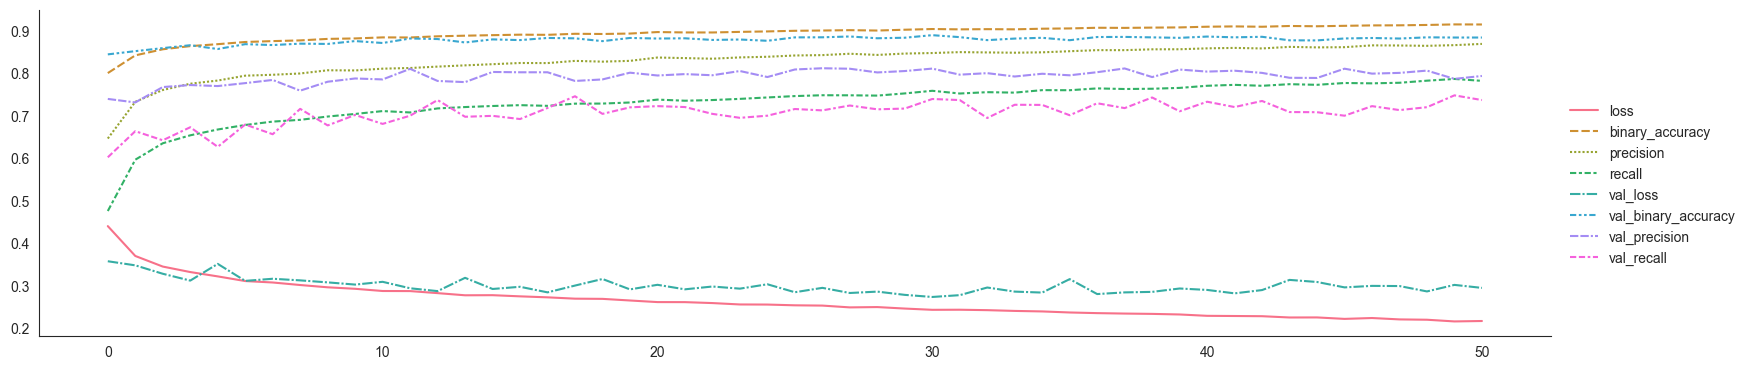

In [53]:
#  Performance Metrics
# Create a line plot using Seaborn's relplot
sns.relplot(data=pd.DataFrame(history.history), kind='line', height=4, aspect=4)
# Show the plot
plt.show()

In [54]:
# Evaluate Model 4 using the test data generator
model03.evaluate(test_gen)

69/69 [==============================] - 6s 78ms/step - loss: 0.2787 - binary_accuracy: 0.8843 - precision: 0.7988 - recall: 0.7287


[0.2786823809146881,
 0.8843393921852112,
 0.7988258600234985,
 0.7286683320999146]

# Models Evaluation Using The Test Dataset

In [55]:
# Import Data 

# Define the path to the preprocessed dataset NPZ file
Preprocessed_dataset = 'Dataset.npz'
# Get a reference to the current module (thismodule)
thismodule = sys.modules[__name__]

# Load data from the NPZ file and assign it to attributes of the current module
with np.load(Preprocessed_dataset) as data:
    for k in data.keys():
        setattr(thismodule, k, data[k].astype(float))

In [56]:
# Confusion Matrix
def print_confusion_matrix(confusion_matrix, axes, class_label, class_names, fontsize=14):
    # Create a DataFrame from the confusion matrix
    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)

    try:
    # Create a heatmap with annotations

        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cbar=False, ax=axes)
    except ValueError:
        raise ValueError("Confusion Matrix Values Must be Integers")
     # Customize the appearance of the heatmap
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    # Set labels and title for the plot
    axes.set_ylabel('True label')
    axes.set_xlabel('Predicted label')
    axes.set_title("Class - " + class_label)

In [57]:
# Provide predictions for each model on the test dataset.
model01 = keras.models.load_model('checkpoints_1/cp.ckpt')
model02 = keras.models.load_model('checkpoints_1/model02.ckpt')
model03 = keras.models.load_model('checkpoints_1/model03.ckpt')


# Ensure that Z_test is cast to integer type
Z_test = Z_test.astype(int)
# Predictions using Model 01
Z_pred_01 = model01.predict(X_test).round().astype(int)
# Predictions using Model 02
Z_pred_02 = model02.predict([X_test, Y_test]).round().astype(int)
# Predictions using Model 03
Z_pred_03 = model03.predict([X_test, Y_test[:, :800, :]]).round().astype(int)



69/69 [==============================] - 3s 42ms/step


# Evaluation Results - Model (1) 

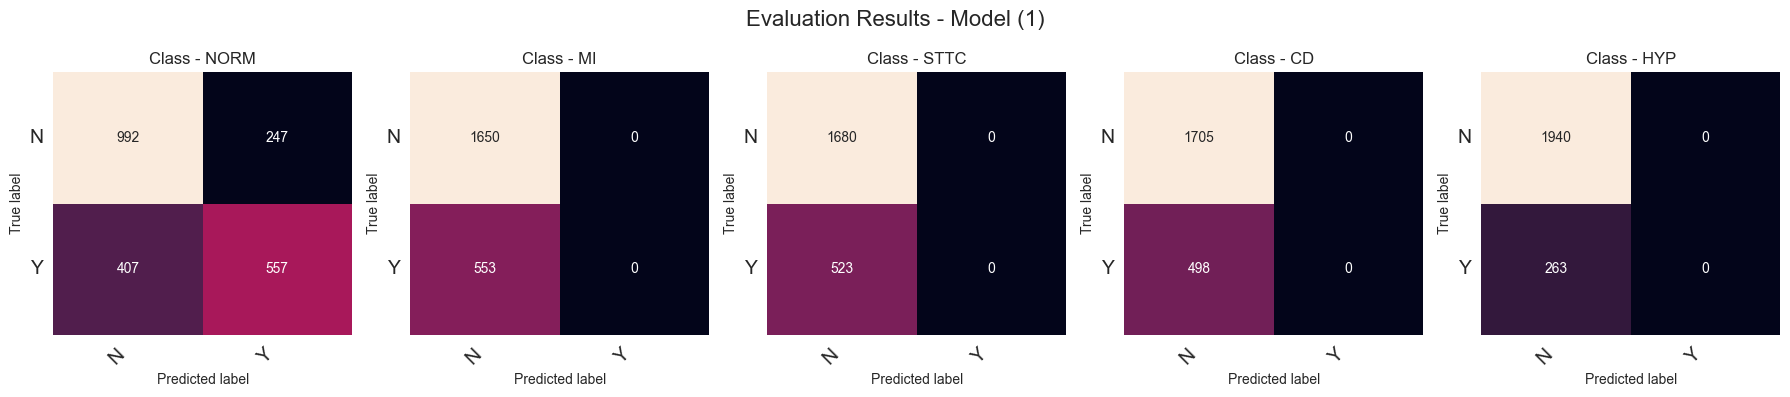

              precision    recall  f1-score   support

        NORM       0.69      0.58      0.63       964
          MI       0.00      0.00      0.00       553
        STTC       0.00      0.00      0.00       523
          CD       0.00      0.00      0.00       498
         HYP       0.00      0.00      0.00       263

   micro avg       0.69      0.20      0.31      2801
   macro avg       0.14      0.12      0.13      2801
weighted avg       0.24      0.20      0.22      2801
 samples avg       0.25      0.25      0.25      2801



In [58]:
# Confuison matrix and classification report

# Provide predictions for each model on the test dataset.
labels=['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Define a custom color palette (you can customize these colors)
custom_palette = sns.color_palette("Blues")

# Create subplots to display confusion matrices
fig, ax = plt.subplots(1, 5, figsize=(18, 4))

# Iterate through confusion matrices, labels, and axes    
for axes, cfs_matrix, label in zip(ax.flatten(), sklearn.metrics.multilabel_confusion_matrix(Z_test, Z_pred_01), labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])

# Add a title to the figure
fig.suptitle('Evaluation Results - Model (1)', fontsize=16)


# Adjust subplot layout for better visualization   
fig.tight_layout()
# Show the plot of confusion matrices
plt.show()


# Generate and print the classification report for Model 01
classification_report = sklearn.metrics.classification_report(Z_test, Z_pred_01, target_names=labels, zero_division=0)
print(classification_report)



# Evaluation Results - Model (2)  

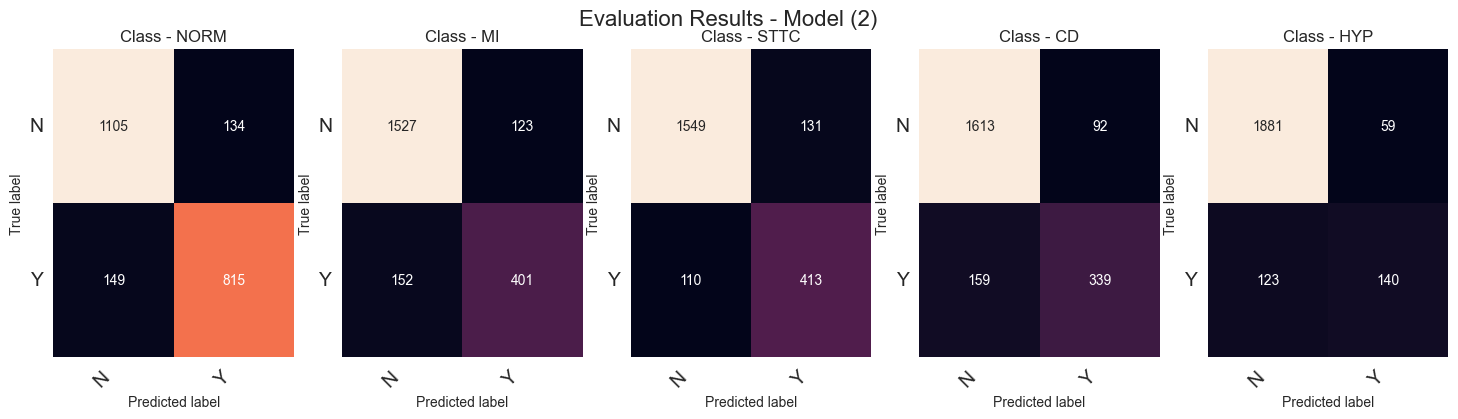

              precision    recall  f1-score   support

        NORM       0.86      0.85      0.85       964
          MI       0.77      0.73      0.74       553
        STTC       0.76      0.79      0.77       523
          CD       0.79      0.68      0.73       498
         HYP       0.70      0.53      0.61       263

   micro avg       0.80      0.75      0.77      2801
   macro avg       0.77      0.71      0.74      2801
weighted avg       0.79      0.75      0.77      2801
 samples avg       0.77      0.76      0.75      2801



In [69]:
# Confuison matrix and classification report 

# Define a custom color palette (you can customize these colors)
custom_palette = sns.color_palette("Blues")

# Create subplots to display confusion matrices
fig, ax = plt.subplots(1, 5, figsize=(18, 4))
# Iterate through confusion matrices, labels, and axes
for axes, cfs_matrix, label in zip(ax.flatten(), sklearn.metrics.multilabel_confusion_matrix(Z_test, Z_pred_02), labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])
# Adjust subplot layout for better visualization

# Add a title to the figure
fig.suptitle('Evaluation Results - Model (2)', fontsize=16)


# Show the plot of confusion matrices
plt.show()
# Generate and print the classification report for Model 02
print(sklearn.metrics.classification_report(Z_test, Z_pred_02, target_names=labels, zero_division=0))

# Evaluation Results - Model (3)  

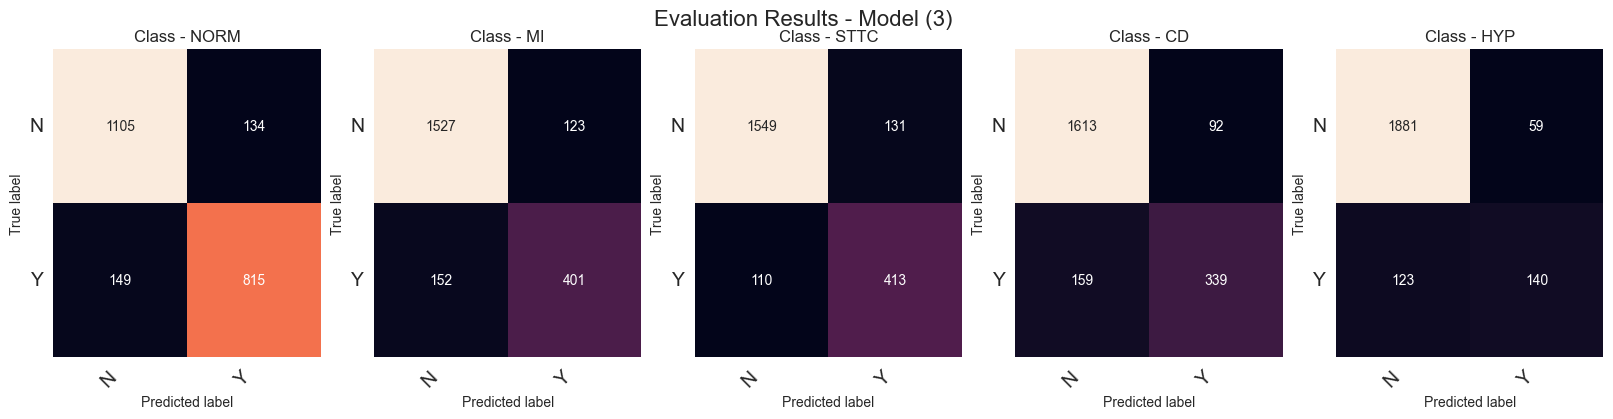

              precision    recall  f1-score   support

        NORM       0.84      0.86      0.85       964
          MI       0.79      0.68      0.73       553
        STTC       0.73      0.77      0.75       523
          CD       0.85      0.61      0.71       498
         HYP       0.72      0.48      0.58       263

   micro avg       0.80      0.73      0.76      2801
   macro avg       0.79      0.68      0.72      2801
weighted avg       0.80      0.73      0.76      2801
 samples avg       0.77      0.74      0.74      2801



In [75]:
# Confuison matrix and classification report 

# Define class labels (assuming 5 classes)
labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# Calculate the multilabel confusion matrix for Model 3 predictions
cfs_matrices = sklearn.metrics.multilabel_confusion_matrix(Z_test, Z_pred_02)

# Create subplots to display confusion matrices
fig, ax = plt.subplots(1, 5, figsize=(20, 4))

# Iterate through confusion matrices, labels, and axes
for axes, cfs_matrix, label in zip(ax.flatten(), cfs_matrices, labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])


# Add a title to the figure
fig.suptitle('Evaluation Results - Model (3)', fontsize=16)


# Show the plot of confusion matrices
plt.show()

# Generate and print the classification report for Model 03
classification_report = sklearn.metrics.classification_report(Z_test, Z_pred_03, target_names=labels, zero_division=0)
print(classification_report)

# Building The application

In [61]:
# Saving the model to use it in the application 
model02.save("model2.h5")

/usr/local/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [76]:
# Load the model 
model = load_model('model2.h5')  
# Check the input shape 2
input_shape = model.input_shape
print("Input shape:", input_shape)


Input shape: [(None, 4), (None, 1000, 12)]


In [67]:
# Make prediction using the model and give results 
import cv2
import numpy as np
from tensorflow.keras.models import load_model




# Load the model
model02 = load_model('model2.h5')


image_path = '/Users/asalaaljazaery/Desktop/ECG samples/1-s2.0-S0022073616301649-gr6.jpg'
ecg_image = cv2.imread(image_path)

input1 = np.array([[30, 1, 180, 99]], dtype=np.float32)  # Example input for the first input of model03

# Convert the image to grayscale
gray_image = cv2.cvtColor(ecg_image, cv2.COLOR_BGR2GRAY)

# Apply thresholding to segment the image (you can adjust the threshold value)
_, segmented_image = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)

# Find contours in the segmented image
contours, _ = cv2.findContours(segmented_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Initialize a list to store segmented regions
segmented_images = []

# Iterate through the contours and extract segmented regions
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    segmented_region = ecg_image[y:y+h, x:x+w]
    segmented_images.append(segmented_region)

# Initialize a list to store extracted signals for each lead
lead_signals = []

# Determine a common shape for all lead signals (e.g., by resizing)
common_shape = (1000, 12)  # Define the desired shape (sequence length, feature dimension)

# Iterate through segmented regions (assuming you have 12 segmented regions)
for i, segmented_region in enumerate(segmented_images):
    # Perform signal extraction (you may use peak detection or other methods)
    # Here, we simply take the grayscale values as the signal
    signal = segmented_region[:, :, 0]  # Assuming the signal is in the blue channel

    # Perform signal processing (you can apply noise filtering or other processing steps here)
    # For example, you can apply Gaussian blur as a simple smoothing filter
    smoothed_signal = cv2.GaussianBlur(signal, (5, 5), 0)

    # Ensure all lead signals have the same shape
    resized_signal = cv2.resize(smoothed_signal, common_shape)

    # Normalize pixel values to the range [0, 1]
    resized_signal = resized_signal / 255.0

    # Append the resized signal to the list of lead signals
    lead_signals.append(resized_signal)

# Convert the list of lead signals into a NumPy array
ecg_signals = np.array(lead_signals)

# Ensure that 'input1' has the same number of samples as 'ecg_signals'
num_samples = ecg_signals.shape[0]
input1 = np.repeat(input1, num_samples, axis=0)

# Transpose the 'ecg_signals' array to match the expected input shape of 'model03'
ecg_signals = ecg_signals.transpose(0, 2, 1)  # Shape: (num_samples, 12, 1000)

# Prepare the input data for prediction
input_data = [input1, ecg_signals]

# Make predictions using the model
result = model02.predict(input_data)

# Assuming 'result' is an array of probabilities, you can extract the class with the highest probability
predicted_class_index = np.argmax(result)

# Replace this with your class labels
class_labels = ["NORM", "MI", "STTC", "CD", "HYP"]

# Get the corresponding class label
predicted_class_label = class_labels[predicted_class_index]

# Print the predicted class label
print("Predicted Class Label:", predicted_class_label)


1/1 [==============================] - 1s 728ms/step
Predicted Class Label: STTC
